# Explicabilidade

https://holisticai.readthedocs.io/en/latest/gallery/tutorials/explainability/examples/example_clinical_records.html

In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import mutual_info_classif

In [46]:
!pip install holisticai
from holisticai.datasets import load_dataset

dataset = load_dataset('clinical_records', protected_attribute="sex")
dataset.data

features          X                                                      \
subfeatures anaemia creatinine_phosphokinase diabetes ejection_fraction   
0                 0                      582        0                20   
1                 0                     7861        0                38   
2                 0                      146        0                20   
3                 1                      111        0                20   
4                 1                      160        1                20   
..              ...                      ...      ...               ...   
294               0                       61        1                38   
295               0                     1820        0                38   
296               0                     2060        1                60   
297               0                     2413        0                38   
298               0                      196        0                45   

features                                                                  \
subfeatures high_blood_pressure  platelets serum_creatinine serum_sodium   
0                             1  265000.00              1.9          130   
1                             0  263358.03              1.1          136   
2                             0  162000.00              1.3          129   
3                             0  210000.00              1.9          137   
4                             0  327000.00              2.7          116   
..                          ...        ...              ...          ...   
294                           1  155000.00              1.1          143   
295                           0  270000.00              1.2          139   
296                           0  742000.00              0.8          138   
297                           0  140000.00              1.4          140   
298                           0  395000.00              1.6          136   

features                  y p_attrs     group_a group_b  
subfeatures smoking time  y     age sex group_a group_b  
0                 0    4  1    75.0   1   False    True  
1                 0    6  1    55.0   1   False    True  
2                 1    7  1    65.0   1   False    True  
3                 0    7  1    50.0   1   False    True  
4                 0    8  1    65.0   0    True   False  
..              ...  ... ..     ...  ..     ...     ...  
294               1  270  0    62.0   1   False    True  
295               0  271  0    55.0   0    True   False  
296               0  278  0    45.0   0    True   False  
297               1  280  0    45.0   1   False    True  
298               1  285  0    50.0   1   False    True  

[299 rows x 15 columns]

In [47]:
print(dataset.data.info())
print('Number of deaths:', dataset['y'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   (X, anaemia)                   299 non-null    int64  
 1   (X, creatinine_phosphokinase)  299 non-null    int64  
 2   (X, diabetes)                  299 non-null    int64  
 3   (X, ejection_fraction)         299 non-null    int64  
 4   (X, high_blood_pressure)       299 non-null    int64  
 5   (X, platelets)                 299 non-null    float64
 6   (X, serum_creatinine)          299 non-null    float64
 7   (X, serum_sodium)              299 non-null    int64  
 8   (X, smoking)                   299 non-null    int64  
 9   (X, time)                      299 non-null    int64  
 10  (y, y)                         299 non-null    int64  
 11  (p_attrs, age)                 299 non-null    float64
 12  (p_attrs, sex)                 299 non-null    int

<Axes: title={'center': 'Correlation matrix'}>

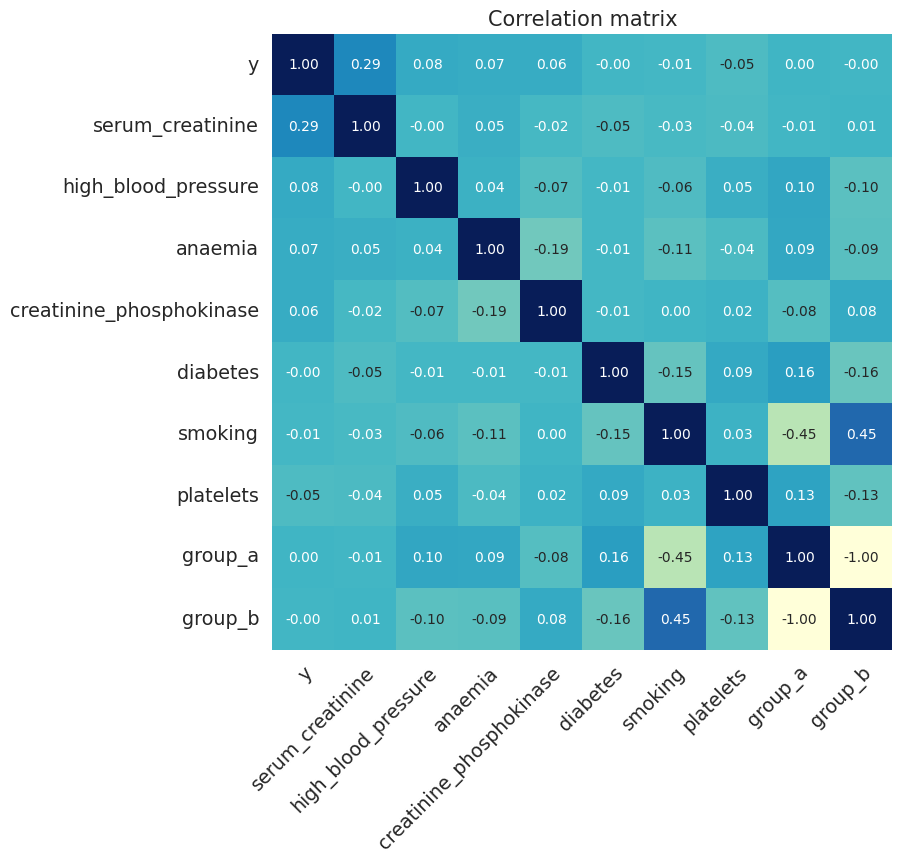

In [48]:
from holisticai.datasets.plots import correlation_matrix_plot

correlation_matrix_plot(dataset, features = ['X'], fixed_features=['group_a', 'group_b'], target_feature='y',  size=(8, 8), n_features=10)

# Predição do Modelo

In [49]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

data = dataset.train_test_split(test_size=0.2, random_state=42)
train = data['train']
test = data['test']

model = LogisticRegression()
model.fit(train['X'], train['y'])

print(classification_report(test['y'], model.predict(test['X'])))

              precision    recall  f1-score   support

           0       0.77      0.94      0.85        35
           1       0.88      0.60      0.71        25

    accuracy                           0.80        60
   macro avg       0.82      0.77      0.78        60
weighted avg       0.82      0.80      0.79        60



In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
# Import the BinaryClassificationProxy class
from holisticai.utils import BinaryClassificationProxy

models = {}

model = RandomForestClassifier()
model.fit(train['X'], train['y'])
models["RandomForestClassifier"] = BinaryClassificationProxy(predict=model.predict, predict_proba=model.predict_proba, classes=model.classes_)

model = XGBClassifier()
model.fit(train['X'], train['y'])
models["XGBClassifier"] = BinaryClassificationProxy(predict=model.predict, predict_proba=model.predict_proba, classes=model.classes_)

model = LogisticRegression(solver='liblinear')
model.fit(train['X'], train['y'])
models["LogisticRegression"] = BinaryClassificationProxy(predict=model.predict, predict_proba=model.predict_proba, classes=model.classes_)

model = MLPClassifier()
model.fit(train['X'], train['y'])
models["MLPClassifier"] = BinaryClassificationProxy(predict=model.predict, predict_proba=model.predict_proba, classes=model.classes_)

In [64]:
models

{'RandomForestClassifier': <holisticai.utils._definitions.BinaryClassificationProxy at 0x7b76f72af990>,
 'XGBClassifier': <holisticai.utils._definitions.BinaryClassificationProxy at 0x7b76f7220d50>,
 'LogisticRegression': <holisticai.utils._definitions.BinaryClassificationProxy at 0x7b76f72ae190>,
 'MLPClassifier': <holisticai.utils._definitions.BinaryClassificationProxy at 0x7b77141d9d10>}

In [51]:
from holisticai.inspection import compute_partial_dependence, compute_permutation_importance

results = {}
for name, model in models.items():

    importances  = compute_permutation_importance(X=train['X'], y=train['y'], proxy=model, n_repeats=10)
    ranked_importances = importances.top_alpha(0.8)

    results[name] ={
        'importances': importances,
        'ranked_importances': ranked_importances,
        'partial_dependencies': compute_partial_dependence(train['X'], features=ranked_importances.feature_names, proxy=model),
        'conditional_importances': compute_permutation_importance(X=train['X'], y=train['y'], proxy=model, importance_type='conditional')
    }

In [68]:
results['RandomForestClassifier']

{'importances': <holisticai.utils._definitions.Importances at 0x7b76f8b42b90>,
 'ranked_importances': <holisticai.utils._definitions.Importances at 0x7b76f8b224d0>,
 'partial_dependencies': <holisticai.utils._definitions.PartialDependence at 0x7b771412e7d0>,
 'conditional_importances': <holisticai.utils._definitions.ConditionalImportances at 0x7b76f9fc5cd0>}

In [52]:
## Parece que feature_postion_stability e outras não existem

# from holisticai.explainability.metrics import xai_ease_score

# metrics  = []
# for name, result in results.items():
#     posi_ctab = feature_position_stability(result['importances'], result['conditional_importances'])
#     fimp_stab = feature_importance_stability(result['importances'], result['conditional_importances'])
#     rank_stab = feature_ranking_stability(result['importances'], result['conditional_importances'])
#     ease_score = xai_ease_score(result['partial_dependencies'], result['ranked_importances'])
#     metrics.append({'name': name, 'posi_stab': posi_stab, 'fimp_stab': fimp_stab, 'rank_stab': rank_stab, 'ease_score':ease_score})

# pd.DataFrame(metrics)

Daqui para baixo funciona mas não entendi qual o sentido

In [53]:
a = results['LogisticRegression']['importances'].as_dataframe().sort_values('Variable', ascending=False)
b = results['LogisticRegression']['conditional_importances'].values['1'].as_dataframe().sort_values('Variable', ascending=False)
c = results['LogisticRegression']['conditional_importances'].values['0'].as_dataframe().sort_values('Variable', ascending=False)
np.mean([np.dot(a['Importance'],b['Importance']), np.dot(a['Importance'],c['Importance'])])

np.float64(0.3134342733857281)

In [69]:
a

,Variable,Importance
0,time,0.957929
9,smoking,0.000000
5,serum_sodium,0.001618
4,serum_creatinine,0.001618
3,platelets,0.008091
8,high_blood_pressure,0.000000
1,ejection_fraction,0.017799
7,diabetes,0.000000
2,creatinine_phosphokinase,0.012945
6,anaemia,0.000000


In [54]:
norm_original = np.linalg.norm(a['Importance'], 2)
a['Importance'] / norm_original

,Importance
0,0.999698
9,0.000000
5,0.001689
4,0.001689
3,0.008443
8,0.000000
1,0.018575
7,0.000000
2,0.013509
6,0.000000


In [55]:
norm_original = np.linalg.norm(b['Importance'], 2)
b['Importance'] / norm_original

,Importance
2,0.258199
9,0.000000
3,0.258199
8,0.000000
1,0.516398
6,0.000000
7,0.000000
5,0.000000
0,0.774597
4,0.000000


In [56]:
def feature_importance_stability(original_importances, conditional_importances):
    original_values = original_importances.as_dataframe().sort_values('Variable', ascending=False)['Importance'].values
    norm_original = np.linalg.norm(original_values)
    sims = []
    for name,fimp in conditional_importances.values.items():
        values = fimp.as_dataframe().sort_values('Variable', ascending=False)['Importance'].values
        norm_resampled = np.linalg.norm(values)
        similarity = np.dot(original_values, values) / (norm_original * norm_resampled)
        sims.append(similarity)
    return np.mean(sims)

<Axes: title={'center': 'Feature Importance'}, xlabel='Importance', ylabel='Features'>

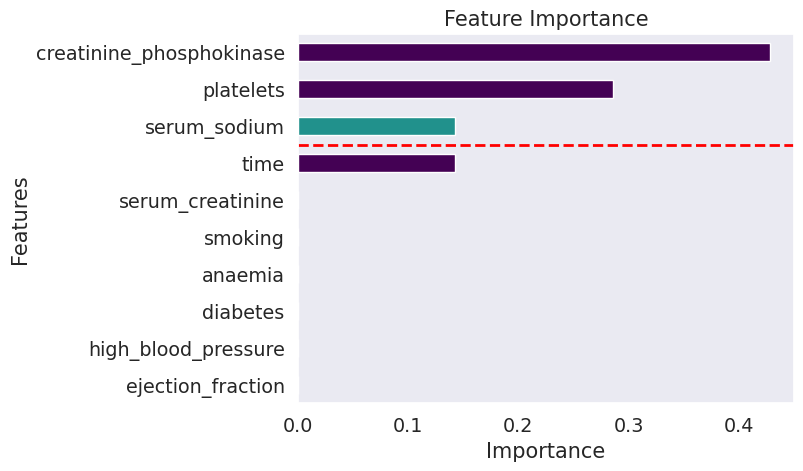

In [57]:
from holisticai.explainability.plots import plot_feature_importance

#plot_feature_importance(results['LogisticRegression']['importances'])
plot_feature_importance(results['LogisticRegression']['conditional_importances'].values['1'])

In [58]:
from holisticai.explainability.metrics import alpha_score
alpha_score(importances)

0.2

In [63]:
from holisticai.utils import RegressionProxy
from holisticai.utils.local_conditional_importances import compute_shap_feature_importance
from holisticai.inspection import compute_partial_dependence

# X = test['X']
# proxy = RegressionProxy(predict=model.predict)

# local_importances = compute_shap_feature_importance(X=X, proxy=proxy)
# local_conditional_importances = local_importances.conditional()

# importances = local_importances.to_global()
# conditional_importances = local_conditional_importances.to_global()

# ranked_importances = importances.top_alpha(0.8)

# partial_dependencies = compute_partial_dependence(X, features=ranked_importances.feature_names, proxy=proxy)

# y_pred = proxy.predict(X)

ModuleNotFoundError: No module named 'holisticai.utils.local_conditional_importances'